In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew
from statsmodels.stats.outliers_influence import variance_inflation_factor

import sys
import os
# Добавляем корень проекта в sys.path
sys.path.insert(0, os.path.abspath('..'))   # если функции в родительской папке
# Определяем корень проекта (папка на уровень выше notebooks/)
root_dir = os.path.abspath('..')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
train = pd.read_csv(os.path.join(root_dir, 'data/saleprice/train.csv'))
test = pd.read_csv(os.path.join(root_dir, 'data/saleprice/test.csv'))
test_ids = test['Id']
train=train.drop('Id',axis=1)
test=test.drop('Id',axis=1)
y = train['SalePrice']
X = train.drop('SalePrice', axis = 1)

X.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

36 численных признака и 43 категориальных

In [5]:
numerical_features = X.select_dtypes(include=[np.number])
nm_index=numerical_features.columns
numeric_list = nm_index.tolist()
print(f"\nNumerical features: {numeric_list}")
skewed_features = X[numeric_list].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_features = skewed_features[abs(skewed_features) > 0.75]
print(skewed_features.head(10))


Numerical features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
MiscVal          24.451640
PoolArea         14.813135
LotArea          12.195142
3SsnPorch        10.293752
LowQualFinSF      9.002080
KitchenAbvGr      4.483784
BsmtFinSF2        4.250888
ScreenPorch       4.117977
BsmtHalfBath      4.099186
EnclosedPorch     3.086696
dtype: float64


Надо придумать, что сделать с признаками с большим хвостом: либо оставить как есть и на этапе preprocesing хвосты уменьшатся(Ruboscaler), либо логорифмировать, clipping либо удалить по квантелям 

In [6]:
missing_ratio = X.isnull().sum() / len(X)
cols_to_drop = missing_ratio[missing_ratio > 0.5].index
print(f"Признаки с пропусками > 50%: {list(cols_to_drop)}")

Признаки с пропусками > 50%: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']


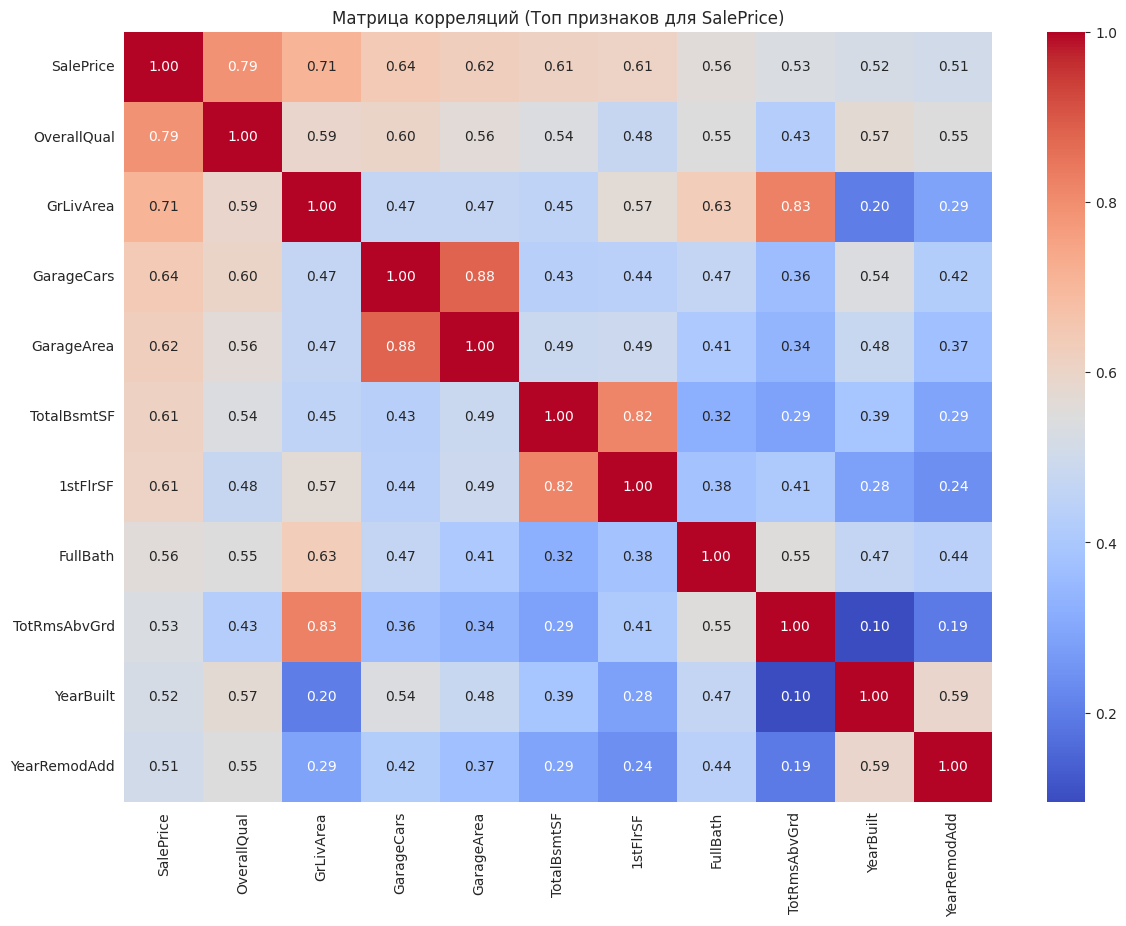

In [7]:
X.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

df = pd.concat([X,y], axis=1)
numeric_df = df.select_dtypes(include=[np.number])
# хочу посмотреть на сильную корреляцию признаков с целевой переменной, чтобы далее оценивать признаки попарно, которые сильно коррелируют с SalePrice
plt.figure(figsize=(14,10))
corr_matrix = numeric_df.corr()
top_corr = corr_matrix['SalePrice'].nlargest(11).index
sns.heatmap(numeric_df[top_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Матрица корреляций (Топ признаков для SalePrice)")
plt.show()

# OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF - корреляция Пирсона >= 0.6
# удалим TotRmsAbvGrd,1stFlrSF,GarageArea

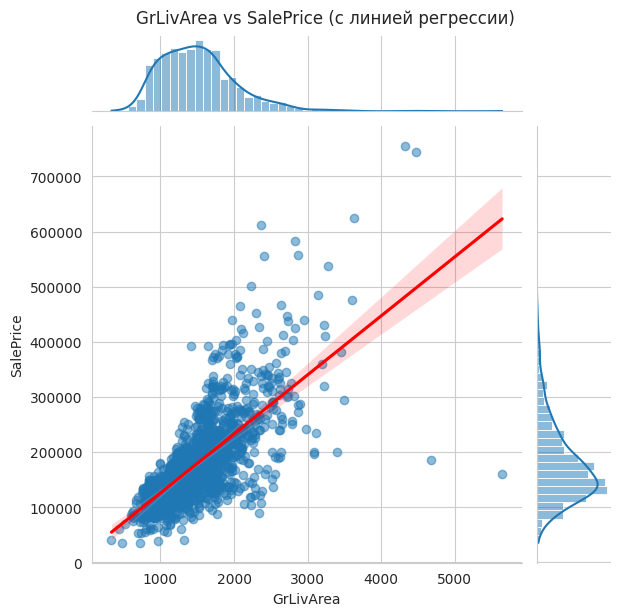

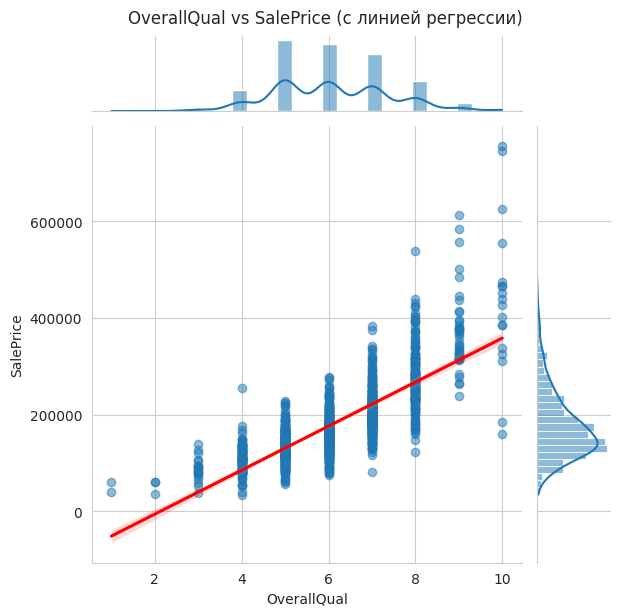

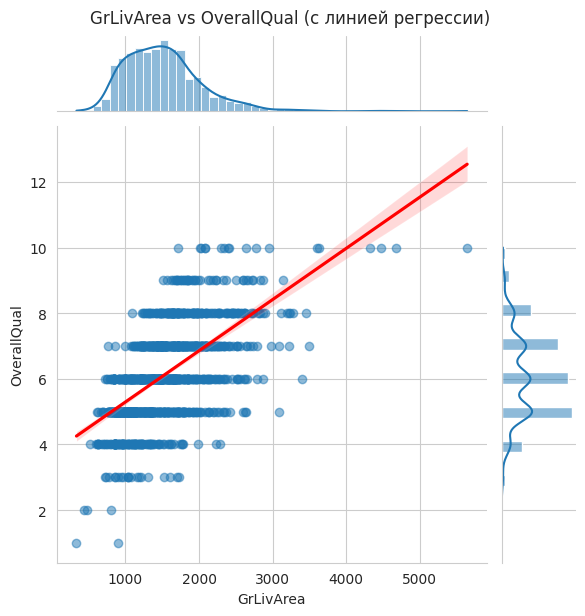

In [8]:
sns.jointplot(data=df, x='GrLivArea', y='SalePrice', kind='reg', 
              scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.suptitle('GrLivArea vs SalePrice (с линией регрессии)', y=1.02)
plt.show()

sns.jointplot(data=df, x='OverallQual', y='SalePrice', kind='reg', 
              scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.suptitle('OverallQual vs SalePrice (с линией регрессии)', y=1.02)
plt.show()


sns.jointplot(data=df, x='GrLivArea', y='OverallQual', kind='reg', 
              scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.suptitle('GrLivArea vs OverallQual (с линией регрессии)', y=1.02)
plt.show()

1. На первом графике видно 4 выброса, разброс цен увиличивается с ростом площади, для элитных домов (>4000 кв. футов) связь менее очевидна из-за малого количества данных
2. Для низкого качества (1-4): цены низкие и разброс маленький
Для высокого качества (8-10): цены высокие, но разброс огромный (от 150k до 700k+)
Выбросы (аномалии):
Низкое качество, высокая цена: несколько домов с OverallQual=4-5, но ценой >200k (возможно, хорошее местоположение)
Высокое качество, низкая цена: дома с OverallQual=9-10, но ценой ~150-200k (возможно, плохой район или срочная продажа)
3. Прослеживается корреляция Площади и качества, в корреляции мпирмена и VIF посмотрю насколько сильно

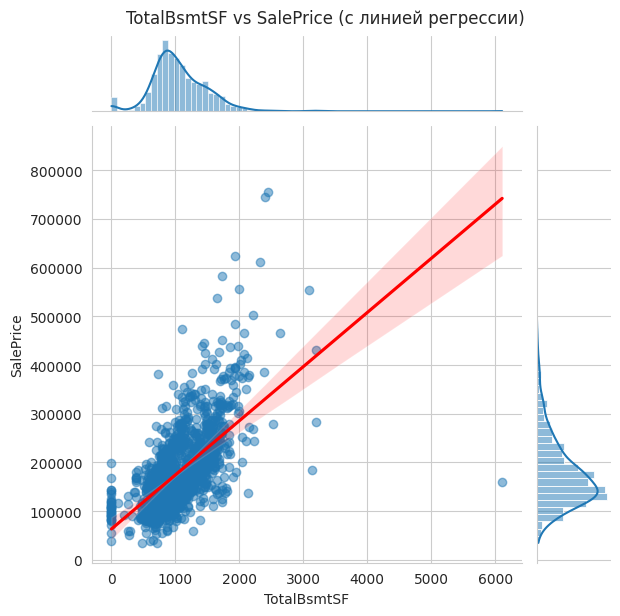

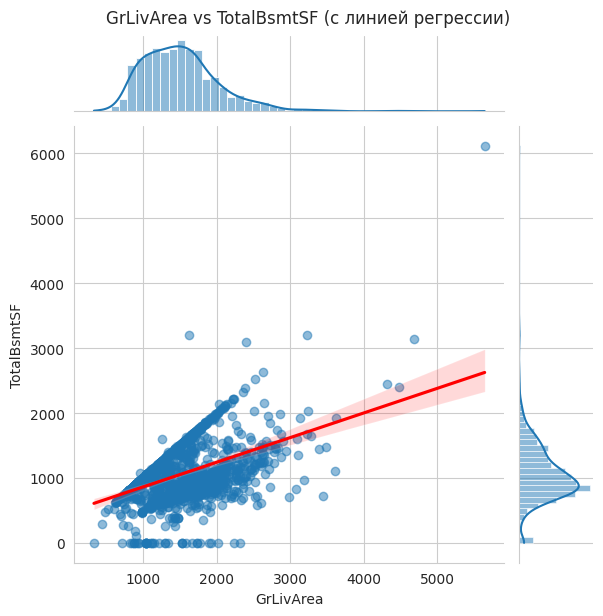

In [9]:
sns.jointplot(data=df, x='TotalBsmtSF', y='SalePrice', kind='reg', 
              scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.suptitle('TotalBsmtSF vs SalePrice (с линией регрессии)', y=1.02)
plt.show()

sns.jointplot(data=df, x='GrLivArea', y='TotalBsmtSF', kind='reg', 
              scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.suptitle('GrLivArea vs TotalBsmtSF (с линией регрессии)', y=1.02)
plt.show()




1. Видна вертикальная линия точек при TotalBsmtSF = 0(Немало домов без подвалов, но и цены не выше 200000)
Выбросы (аномалии):
Два дома с подвалом ~2500 кв. футов и ценой ~750k (выброс сверху)
Несколько домов с подвалом >3000 кв. футов, но относительно низкой ценой
Дом с подвалом ~6000 кв. футов (крайний выброс справа) — очень редкий случай
Разброс цен увеличивается с ростом площади подвала
Доверительный интервал (розовая область) расширяется
Распределения:
TotalBsmtSF: правостороннее смещение (большинство подвалов 0-2000 кв. футов)
SalePrice: также скошено вправо
2. Есть корреляция, но не слишком сильная
Много разброса: есть дома с большой жилой площадью, но маленьким подвалом (и наоборот)
При маленькой жилой площади (1000-2000 кв. футов) подвалы тоже небольшие
При большой жилой площади (>250 кв. футов) подвалы могут быть любыми
Есть экстримальный выброс
Красная линия регрессии проходит не идеально
Связь может быть нелинейной

Проверить VIF и корреляцию Спирмена
Скорее всего нилейные связи не портят линейную модель, так как матрица будет плохо обусловленной(близка к необротимой), если только линейные зависимости между столбцами. В этом случае достаточно корреляции Пирсона, хотя корреляция подразумевает нормальное распределение данных или близкое к нему, но по предельной центральной теореме при большой выборке происходит стремление к нормальному распределению

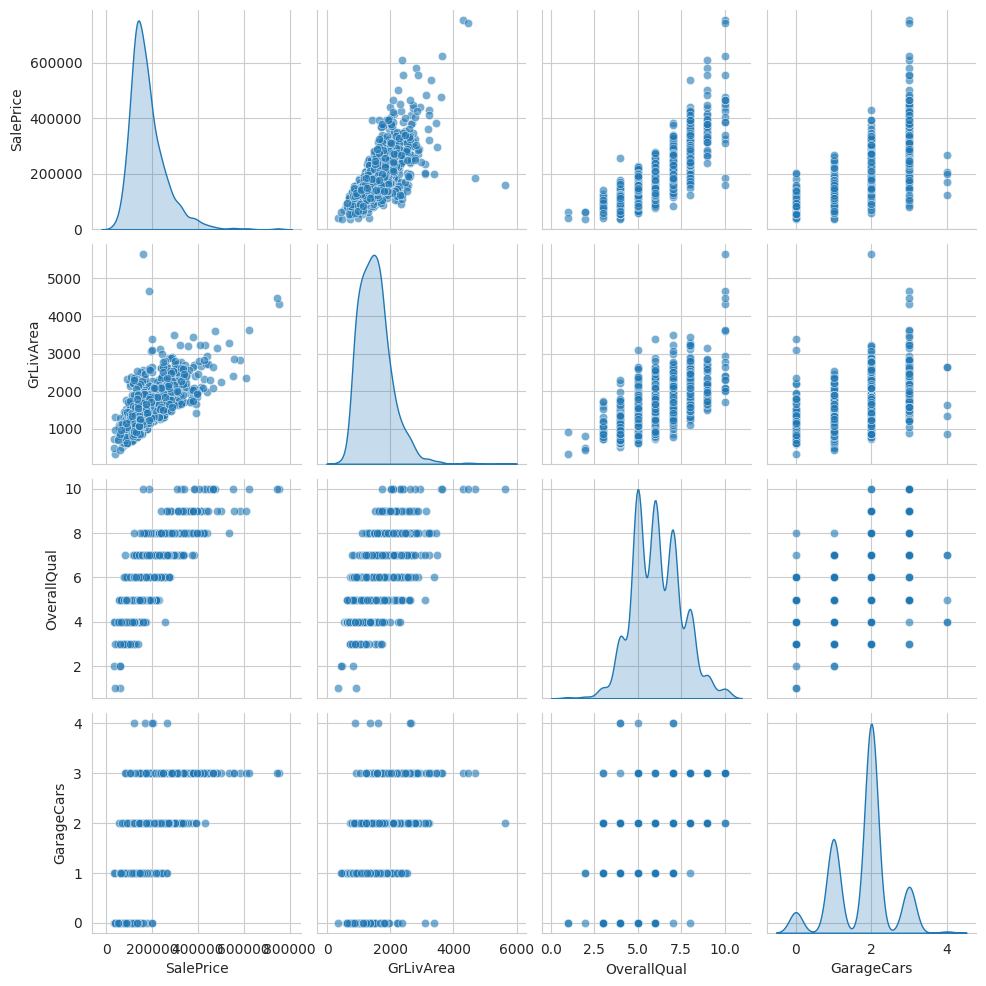

In [10]:
sns.pairplot(df[['SalePrice', 'GrLivArea', 'OverallQual', 'GarageCars']], 
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.show()

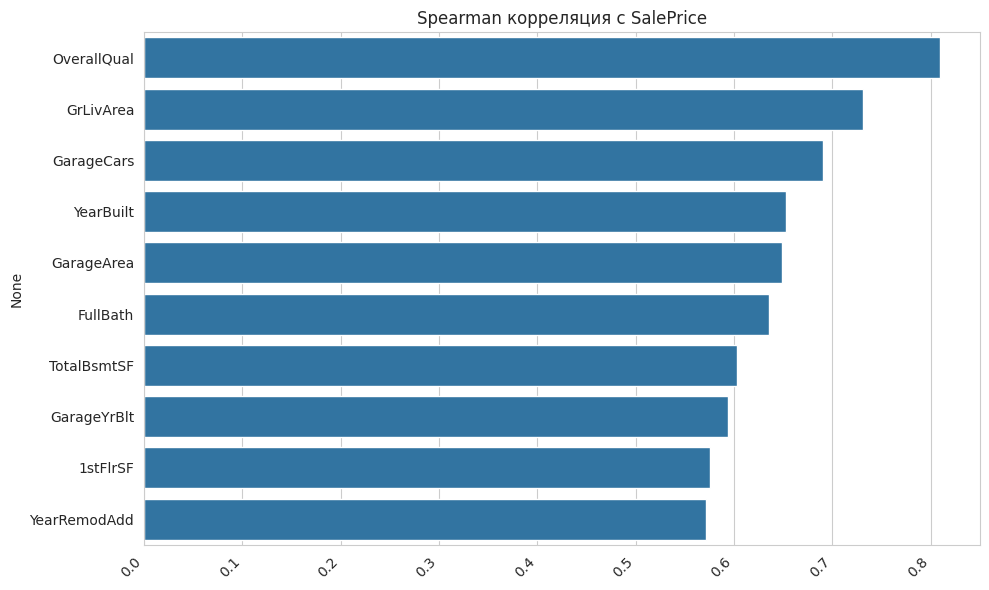


Топ-10 признаков по Spearman:
SalePrice       1.000000
OverallQual     0.809829
GrLivArea       0.731310
GarageCars      0.690711
YearBuilt       0.652682
GarageArea      0.649379
FullBath        0.635957
TotalBsmtSF     0.602725
GarageYrBlt     0.593788
1stFlrSF        0.575408
YearRemodAdd    0.571159
Name: SalePrice, dtype: float64


In [11]:
# Корреляция спирмена признаков с saleprice
spearman_matrix = df.select_dtypes(include=[np.number]).corr(method='spearman')

# Визуализация топ-10 корреляций с SalePrice
top_corr = spearman_matrix['SalePrice'].nlargest(11)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values[1:], y=top_corr.index[1:])  # Исключаем SalePrice с самим собой
plt.title('Spearman корреляция с SalePrice')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nТоп-10 признаков по Spearman:")
print(top_corr)

In [12]:
spearman_corr, p_value = stats.spearmanr(df['OverallQual'], df['GrLivArea'])
print(f"Spearman корреляция (OverallQual, GrLivArea): {spearman_corr:.4f}")
print(f"P-value: {p_value:.4e}")

spearman_corr, p_value = stats.spearmanr(df['OverallQual'], df['TotalBsmtSF'])
print(f"Spearman корреляция (OverallQual, TotalBsmtSF ): {spearman_corr:.4f}")
print(f"P-value: {p_value:.4e}")

spearman_corr, p_value = stats.spearmanr(df['GrLivArea'], df['TotalBsmtSF'])
print(f"Spearman корреляция (GrLivArea, TotalBsmtSF ): {spearman_corr:.4f}")
print(f"P-value: {p_value:.4e}")

Spearman корреляция (OverallQual, GrLivArea): 0.6033
P-value: 1.9783e-145
Spearman корреляция (OverallQual, TotalBsmtSF ): 0.4599
P-value: 2.6050e-77
Spearman корреляция (GrLivArea, TotalBsmtSF ): 0.3710
P-value: 7.2171e-49


подтвердились нелинейные связи, которые были видны на парных графиках. P-value показывает, что связи значимы, то-есть гипотеза подверждается. 

In [13]:

def calculate_vif(X, threshold=5.0):
    """
    Рассчитывает VIF для каждого признака
    
    Parameters:
    -----------
    X : DataFrame
        Матрица признаков (только числовые)
    threshold : float
        Порог VIF для выделения проблемных признаков
    
    Returns:
    --------
    vif_df : DataFrame
        Таблица с VIF значениями
    """
    # Добавляем константу (intercept)
    X_const = X.copy()
    X_const['const'] = 1
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    
    # Считаем VIF для каждого признака
    vif_data["VIF"] = [
        variance_inflation_factor(X_const.values, i) 
        for i in range(len(X.columns))
    ]
    
    # Сортируем по убыванию VIF
    vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)
    
    # Добавляем метку "проблемный"
    vif_data["problematic"] = vif_data["VIF"] > threshold
    
    return vif_data


X_numeric = X[numeric_list].copy()

# Заполняем пропуски (VIF не работает с NaN)
X_numeric = X_numeric.fillna(X_numeric.median())

# Считаем VIF
vif_results = calculate_vif(X_numeric, threshold=5.0)

print("=== VIF до обработки ===\n")
print(vif_results.to_string(index=False))
print(f"\nПроблемных признаков (VIF > 5): {vif_results['problematic'].sum()}")

/home/andrew/ml/my_project/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


=== VIF до обработки ===

      feature      VIF  problematic
   BsmtFinSF1      inf         True
   BsmtFinSF2      inf         True
    BsmtUnfSF      inf         True
  TotalBsmtSF      inf         True
    GrLivArea      inf         True
 LowQualFinSF      inf         True
     2ndFlrSF      inf         True
     1stFlrSF      inf         True
   GarageCars 5.584096         True
   GarageArea 5.459691         True
    YearBuilt 5.008529         True
 TotRmsAbvGrd 4.885254        False
  GarageYrBlt 3.311239        False
  OverallQual 3.259088        False
     FullBath 2.951509        False
 YearRemodAdd 2.423196        False
 BedroomAbvGr 2.328625        False
 BsmtFullBath 2.219660        False
     HalfBath 2.167109        False
   MSSubClass 1.655962        False
  OverallCond 1.595457        False
 KitchenAbvGr 1.593686        False
   Fireplaces 1.585276        False
  LotFrontage 1.568127        False
   MasVnrArea 1.389441        False
EnclosedPorch 1.283824        False
  

есть бесконечность, потому что некоторые признаки комбинации:
### Сумма BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF=TotalBsmtSF
### 1stFlrSF + 2ndFlrSF + LowQualFinSF=GrLivArea
Можно удалить LowQualFinSF и BsmtFinSF2, так как много 0 значений
также удалю TotalBsmtSF, GrLivArea - так как линейные комбинации
### Выбросы тогда не надо удалять для этих признаков, которые были видны на парных графиках, так как эти признаки удалю
Также удалю GarageArea, GarageYrBlt - чтобы избавиться от мультиколлинеарности, корреляция у этих признаков в SalePrice ниже чем у тех с кем они коррелируют



# Пропуски
- Пропуски числовые - 0, так как пропуск - это отсутствие
- Пропуски категориальные - None, так как большинство пропусков-это отсутствие той или иной части

# Кодирование
1. Обычные категориальные признаки закодирую one-hot, у которых много уникальных значений - target по медиане ?(медианой хорошо, когда распределение скошенно). В EDA исследовал Neighborhood(там больше всего уникальных значений)
2. Порядковые признаки-target encoding(средним)


In [14]:
#ПОРЯДКОВЫЕ ПРИЗНАКИ (Ordinal Features)

# 1. Общая оценка качества и состояния (шкала 1-10)
ordinal_1_10 = ['OverallQual', 'OverallCond']

# 2. Качество и состояние (шкала Po, Fa, TA, Gd, Ex)
ordinal_quality = [
    'ExterQual',    # Качество внешних материалов
    'ExterCond',    # Состояние внешних материалов
    'BsmtQual',     # Высота подвала
    'BsmtCond',     # Общее состояние подвала
    'HeatingQC',    # Качество отопления
    'KitchenQual',  # Качество кухни
    'FireplaceQu',  # Качество камина
    'GarageQual',   # Качество гаража
    'GarageCond',   # Состояние гаража
    'PoolQC'        # Качество бассейна
]

# 3. Отделка подвала (шкала Unf, LwQ, Rec, BLQ, ALQ, GLQ)
ordinal_bsmt_finish = ['BsmtFinType1', 'BsmtFinType2']

# 4. Воздействие подвала (шкала No, Mn, Av, Gd)
ordinal_exposure = ['BsmtExposure']

# 5. Отделка гаража (шкала Unf, RFn, Fin)
ordinal_garage_finish = ['GarageFinish']

# 6. Функциональность дома (шкала Sal, Severe, Maj2, Maj1, Mod, Min2, Min1, Typ)
ordinal_functional = ['Functional']

# 7. Тип улицы и подъездной дороги (Grvl, Pave)
ordinal_street = ['Street', 'Alley']

# 8. Мощеная подъездная дорога (N, P, Y)
ordinal_paved_drive = ['PavedDrive']

# 9. Центральное кондиционирование (N, Y)
ordinal_central_air = ['CentralAir']

# 10. Тип забора (MnWw, GdWo, MnPrv, GdPrv)
ordinal_fence = ['Fence']

# Объединяем все порядковые признаки
all_ordinal_features = (
    ordinal_1_10 + 
    ordinal_quality + 
    ordinal_bsmt_finish + 
    ordinal_exposure + 
    ordinal_garage_finish + 
    ordinal_functional + 
    ordinal_street + 
    ordinal_paved_drive + 
    ordinal_central_air + 
    ordinal_fence
)

print(f"Всего порядковых признаков: {len(all_ordinal_features)}")
print("\nСписок:")
for feat in all_ordinal_features:
    print(f"  - {feat}")

Всего порядковых признаков: 22

Список:
  - OverallQual
  - OverallCond
  - ExterQual
  - ExterCond
  - BsmtQual
  - BsmtCond
  - HeatingQC
  - KitchenQual
  - FireplaceQu
  - GarageQual
  - GarageCond
  - PoolQC
  - BsmtFinType1
  - BsmtFinType2
  - BsmtExposure
  - GarageFinish
  - Functional
  - Street
  - Alley
  - PavedDrive
  - CentralAir
  - Fence


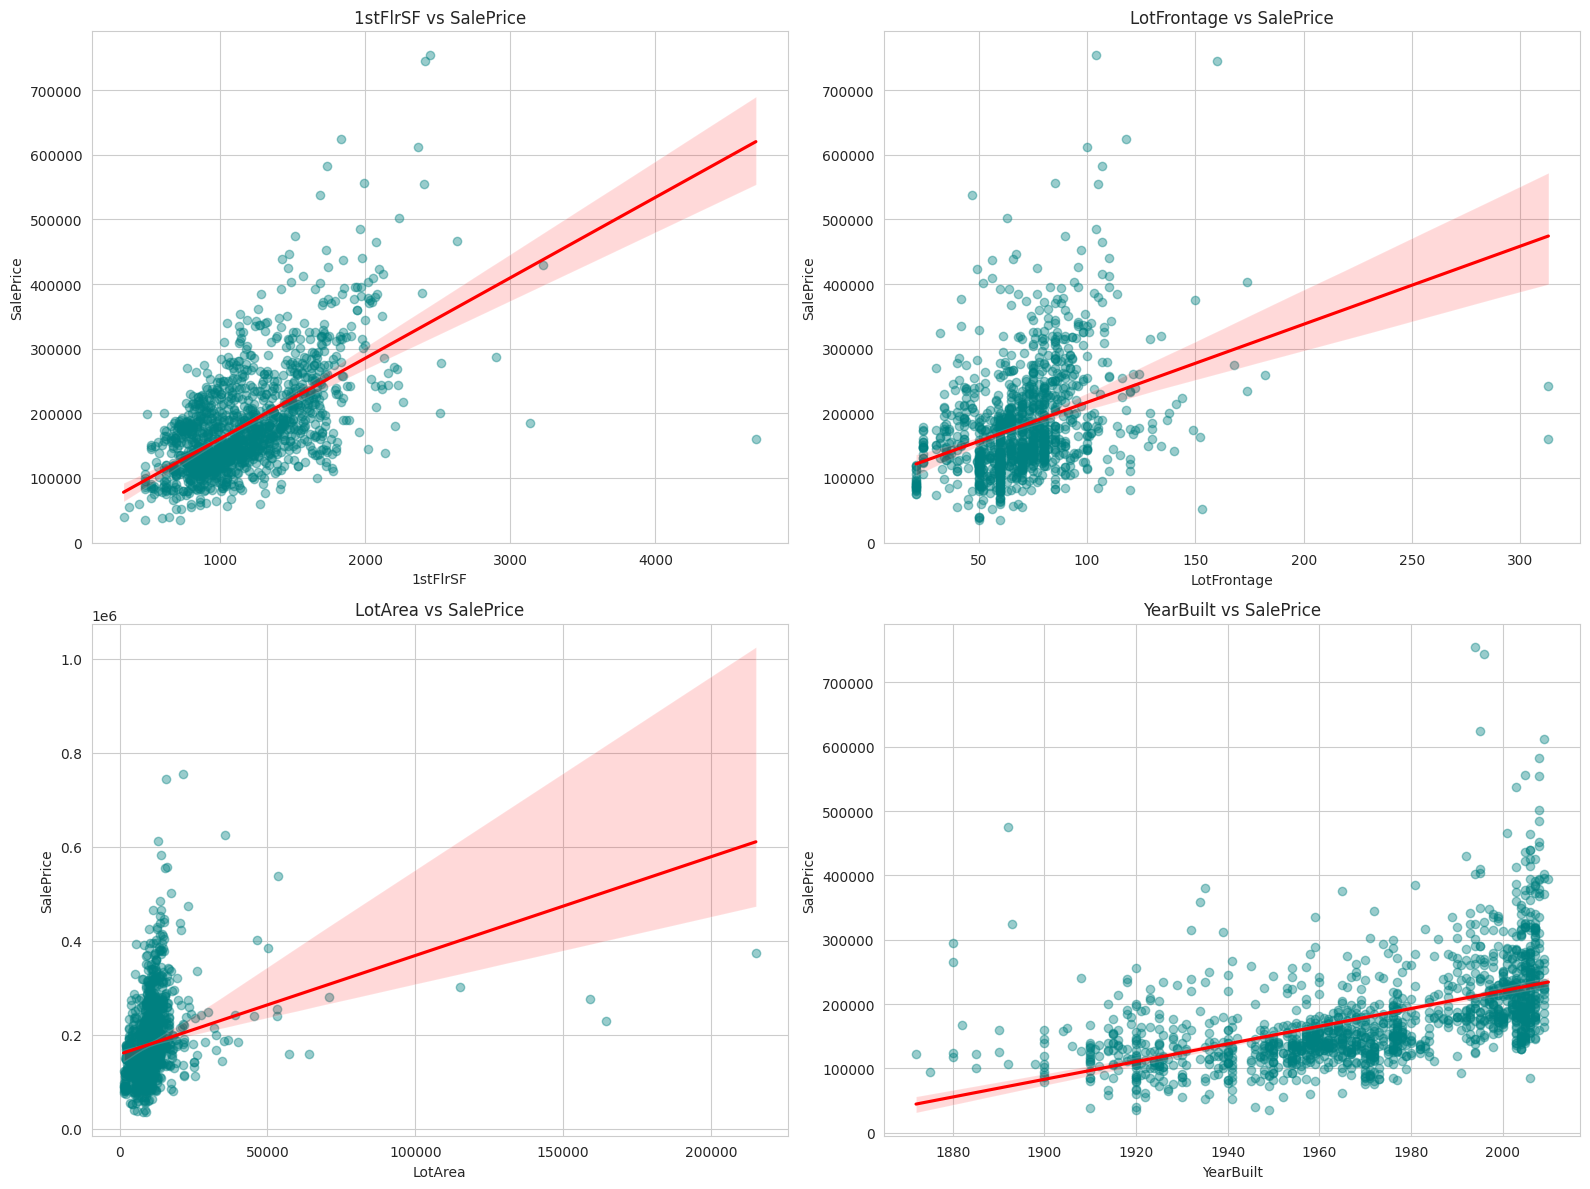

In [16]:
# можно проанализировать выбросы через парные графики в важных признаках для дома: 1stFlrSF,GarageCars,LotFrontage,LotArea,YearBuilt
features_to_check = ['1stFlrSF', 'LotFrontage', 'LotArea','YearBuilt'] #GarageCars - дискретный признак, пока не трогаю
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_check):
    sns.regplot(data=df, x=col, y='SalePrice', ax=axes[i],
                scatter_kws={'alpha':0.4, 'color': 'teal'},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()


### 1 график
Правый нижний угол есть аномалии 2-3, так как площадь большая, но маленькая цена. Скорее всего эти же аномалии прослеживались в GrLivArea(по структуре графике очень похожи) - так как GrLivArea линейая комбинация площадей частей дома, а первый этаж самый важный
### 2 график Протяженность участка по улице
крайняя правая часть > 200 футов примерно. Это чересчур много.Видно 2 аномалии.Они и стоят дешево
### 3 график Общая площадь участка
Правая часть сильно вытинута, 4 точки аномалии - LotArea > 100000 примерно
### 4 
Общая структура - чем новее тем дороже. Дома <1880 года очень подозрительны. Годы > 2000, но цена < 100000 - аномалия. Новый дом не может стоить так дешево

In [20]:
anomaly_rules = {
    '1stFlrSF (Огромная площадь, низкая цена)': 
        (df['1stFlrSF'] > 3500) & (df['SalePrice'] < 200000),
        
    'LotFrontage (Нереалистично длинный фронт > 200 футов)': 
        (df['LotFrontage'] > 200),
        
    'LotArea (Сельхозземли > 100 000 кв. футов)': 
        (df['LotArea'] > 100000),
        
    'YearBuilt (Старые < 1880 или Новые > 2005, но дешевые < 100k)': 
        (df['YearBuilt'] < 1880) | ((df['YearBuilt'] > 2000) & (df['SalePrice'] < 100000))
}

# Считаем количество по каждому правилу
report = []
for rule_name, condition in anomaly_rules.items():
    count = condition.sum()
    report.append({
        'Правило': rule_name,
        'Удалено строк': count
    })

report_df = pd.DataFrame(report)
print(report_df.to_string(index=False))

# Объединяем все условия через ИЛИ (|), чтобы создать общую маску
# Мы используем pd.Series(False, index=df.index) как безопасную базу
total_outlier_mask = pd.Series(False, index=df.index)

for condition in anomaly_rules.values():
    total_outlier_mask |= condition

print(f"Всего уникальных строк подпадает под правила: {total_outlier_mask.sum()}")
print(f"Размер датасета до очистки: {len(df)}")

# Удаляем аномалии
df_clean = df[~total_outlier_mask].copy()

print(f"Размер датасета после очистки: {len(df_clean)}")
print(f"Итого удалено аномалий: {len(df) - len(df_clean)} ({((len(df) - len(df_clean))/len(df)*100):.2f}% данных)")

                                                      Правило  Удалено строк
                     1stFlrSF (Огромная площадь, низкая цена)              1
        LotFrontage (Нереалистично длинный фронт > 200 футов)              2
                   LotArea (Сельхозземли > 100 000 кв. футов)              4
YearBuilt (Старые < 1880 или Новые > 2005, но дешевые < 100k)              3
Всего уникальных строк подпадает под правила: 9
Размер датасета до очистки: 1460
Размер датасета после очистки: 1451
Итого удалено аномалий: 9 (0.62% данных)


# Добавил этот блок кода в src в preprocess.py в виде функций, позже сделаю импорт, чтобы код был чище